In [3]:
import pandas as pd
from pathlib import Path

def load_processed_tables(
    out_dir: str | Path,
    prefix: str = "tx_shoreline",
    format: str = "parquet",
):
    out_dir = Path(out_dir)

    if format == "parquet":
        shoreline_df = pd.read_parquet(out_dir / f"{prefix}_obs.parquet")
        transects = pd.read_parquet(out_dir / f"{prefix}_transects.parquet")
        stats = pd.read_parquet(out_dir / f"{prefix}_stats.parquet")
    elif format == "csv":
        shoreline_df = pd.read_csv(out_dir / f"{prefix}_obs.csv", parse_dates=["datetime"])
        transects = pd.read_csv(out_dir / f"{prefix}_transects.csv")
        stats = pd.read_csv(out_dir / f"{prefix}_stats.csv")
    else:
        raise ValueError("format must be 'parquet' or 'csv'")

    return shoreline_df, transects, stats

shoreline_df, transects, stats = load_processed_tables(
    "F:/crs/proj/2026_shoreline_analysis/processed",
    prefix="tx_shoreline",
    format="parquet",
)

# rename for convenience
df_loess = shoreline_df.copy()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# CORE LOWESS (USED EVERYWHERE)
# ============================================================
def loess_time_grid(t_days, y, tgrid_days, window_days=90, min_points=5):

    t = np.asarray(t_days, float)
    y = np.asarray(y, float)
    tg = np.asarray(tgrid_days, float)

    yhat = np.full_like(tg, np.nan, float)
    npts = np.zeros_like(tg, int)

    for j, t0 in enumerate(tg):

        dt = np.abs(t - t0)
        mask = np.isfinite(dt) & np.isfinite(y) & (dt <= window_days)

        if np.sum(mask) < min_points:
            continue

        tj = t[mask]
        yj = y[mask]

        w = (1 - (dt[mask] / window_days)**3)**3

        X = np.vstack([np.ones_like(tj), tj - t0]).T
        WX = X * w[:, None]

        beta = np.linalg.pinv(X.T @ WX) @ (X.T @ (w * yj))

        yhat[j] = beta[0]
        npts[j] = np.sum(mask)

    return yhat, npts


# ============================================================
# BUILD GRIDDED LOESS FOR ALL TRANSECTS
# ============================================================
def build_loess_grid(df, freq, window_days, min_points):

    t0 = df["datetime"].min()

    t_days = (df["datetime"] - t0).dt.total_seconds() / 86400

    tgrid = pd.date_range(df["datetime"].min(),
                          df["datetime"].max(),
                          freq=freq)

    tgrid_days = (tgrid - t0).total_seconds() / 86400

    transects = (
        df.groupby("ID", as_index=False)["s_km"]
        .first()
        .sort_values("s_km")
    )

    ids = transects["ID"].values
    s = transects["s_km"].values

    M = np.full((len(tgrid), len(ids)), np.nan)

    for j, tid in enumerate(ids):

        g = df[df["ID"] == tid]

        yhat, _ = loess_time_grid(
            t_days[g.index],
            g["distance"].values,
            tgrid_days,
            window_days=window_days,
            min_points=min_points
        )

        M[:, j] = yhat

    return tgrid, s, M, ids


# ============================================================
# HEATMAP PLOT
# ============================================================
def plot_heatmap(tgrid, s, M, title, vmin=None, vmax=None,
                 places=None, storms=None):

    fig, ax = plt.subplots(figsize=(11, 7))

    ynum = mdates.date2num(tgrid.to_pydatetime())

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="none",
        extent=[s.min(), s.max(), ynum[-1], ynum[0]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlabel("Alongshore distance (km)")
    ax.set_ylabel("Time")
    ax.set_title(title)

    ax.yaxis_date()

    # --------------------------------------------------------
    # PLACE NAMES
    # --------------------------------------------------------
    if places is not None:
        for _, r in places.iterrows():
            ax.text(r["s_km"], ynum[0],
                    r["Place_name"],
                    rotation=90,
                    va="bottom",
                    fontsize=8)

    # --------------------------------------------------------
    # HURRICANES
    # --------------------------------------------------------
    if storms is not None:
        for _, r in storms.iterrows():
            ax.text(r["s_km"], mdates.date2num(r["landfall_time"]),
                    r["storm_name"],
                    fontsize=8,
                    bbox=dict(facecolor="lightgray", alpha=0.7, pad=1))

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Shoreline position (m)")

    fig.tight_layout()
    return fig, ax


# ============================================================
# LOAD ANNOTATION DATA
# ============================================================
places = pd.read_csv("F:/crs/proj/2026_shoreline_analysis/place_names.csv")
storms = pd.read_csv("F:/crs/proj/2026_shoreline_analysis/hurricanes.csv")

storms["landfall_time"] = pd.to_datetime(storms["landfall_time"])

# ------------------------------------------------------------
# MAP PLACE NAMES TO ALONGSHORE DISTANCE (nearest transect)
# ------------------------------------------------------------
transects = df_loess.groupby("ID", as_index=False).first()

xy = transects[["shoreline_x", "shoreline_y"]].values
svals = transects["s_km"].values

from scipy.spatial import cKDTree
tree = cKDTree(xy)

pts = places[["Longitude", "Latitude"]].values
dist, idx = tree.query(pts)

places["s_km"] = svals[idx]


# ============================================================
# BUILD ALL GRIDS
# ============================================================

# Monthly
t_m, s_m, M_m, _ = build_loess_grid(
    df_loess,
    freq="MS",
    window_days=90,
    min_points=5
)

# Seasonal (DJF, MAM, JJA, SON)
t_q, s_q, M_q, _ = build_loess_grid(
    df_loess,
    freq="QS-DEC",
    window_days=180,
    min_points=8
)

# Annual
t_a, s_a, M_a, _ = build_loess_grid(
    df_loess,
    freq="AS",
    window_days=365,
    min_points=12
)

C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_41076\3877909194.py:51: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  tgrid = pd.date_range(df["datetime"].min(),


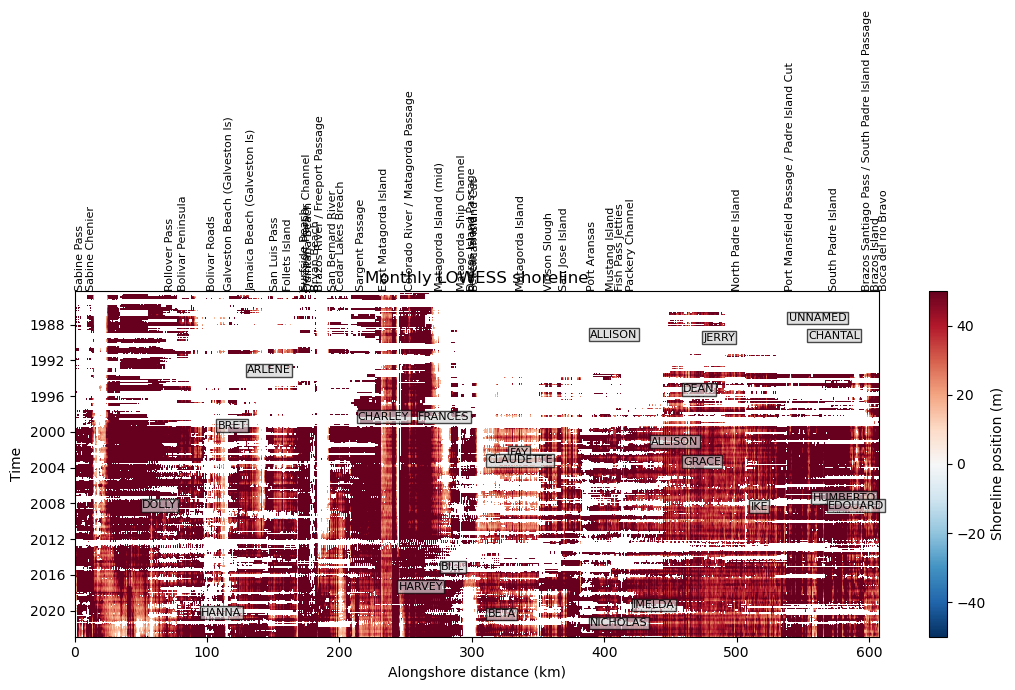

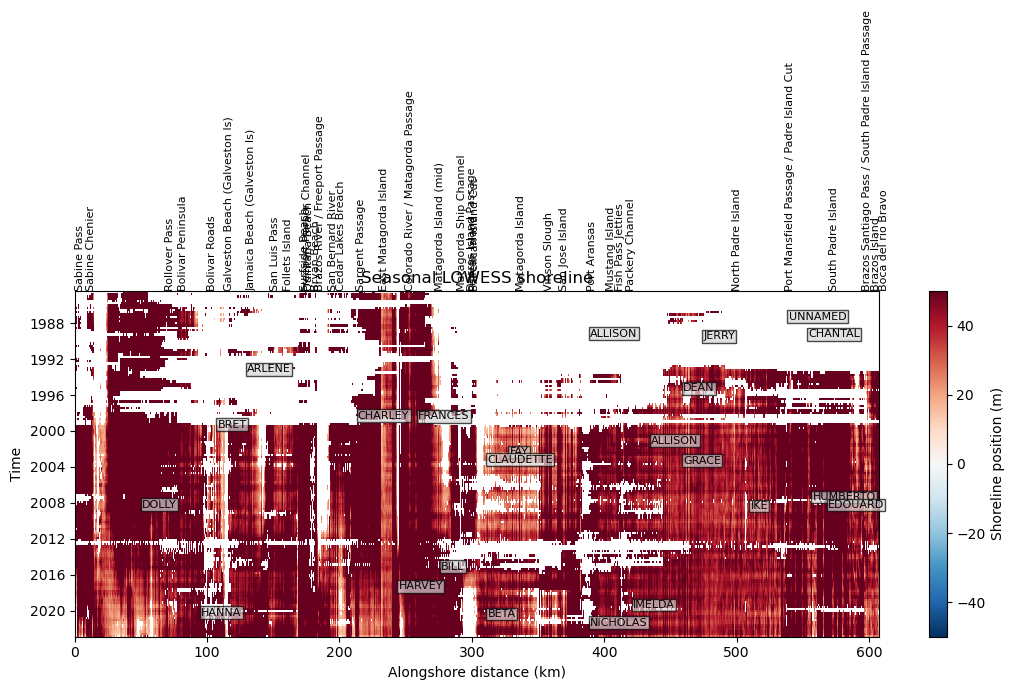

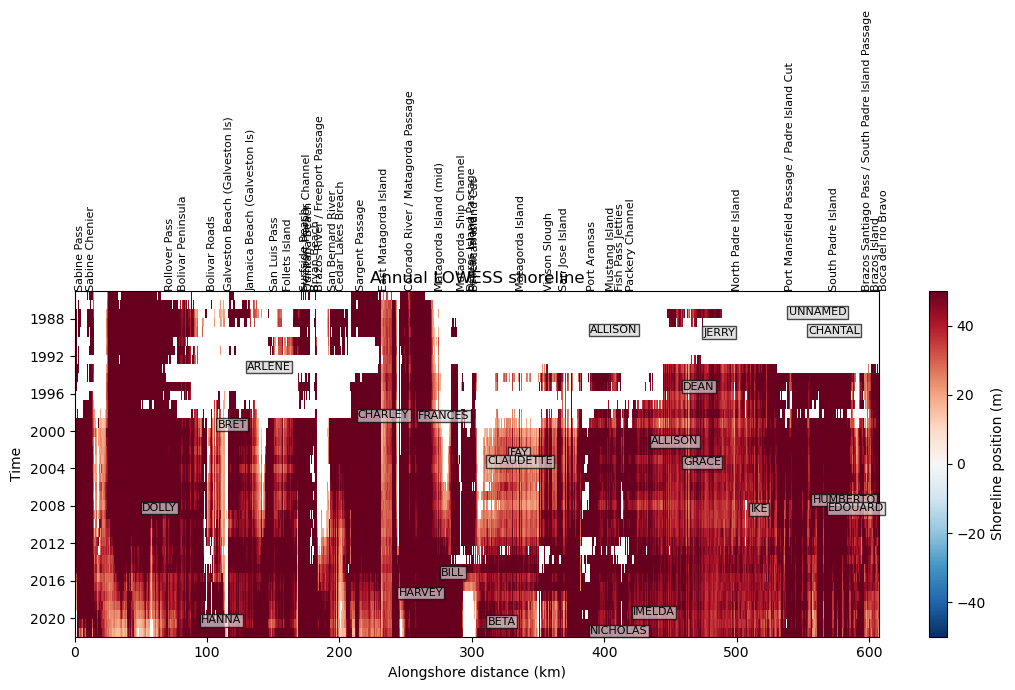

In [ ]:
# ============================================================
# PLOT
# ============================================================

fig1, ax1 = plot_heatmap(
    t_m, s_m, M_m,
    "Monthly LOWESS shoreline",
    vmin=-50, vmax=50,
    places=places,
    storms=storms
)

fig2, ax2 = plot_heatmap(
    t_q, s_q, M_q,
    "Seasonal LOWESS shoreline",
    vmin=-50, vmax=50,
    places=places,
    storms=storms
)

fig3, ax3 = plot_heatmap(
    t_a, s_a, M_a,
    "Annual LOWESS shoreline",
    vmin=-50, vmax=50,
    places=places,
    storms=storms
)

plt.show()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SAVE LOESS GRIDS
# ============================================================
out_dir = Path("F:/crs/proj/2026_shoreline_analysis/loess_grids")
out_dir.mkdir(parents=True, exist_ok=True)

# save matrices as compressed numpy
np.savez_compressed(
    out_dir / "loess_monthly_grid.npz",
    tgrid=t_m.values.astype("datetime64[ns]"),
    s_km=s_m,
    M=M_m,
)

np.savez_compressed(
    out_dir / "loess_seasonal_grid.npz",
    tgrid=t_q.values.astype("datetime64[ns]"),
    s_km=s_q,
    M=M_q,
)

np.savez_compressed(
    out_dir / "loess_annual_grid.npz",
    tgrid=t_a.values.astype("datetime64[ns]"),
    s_km=s_a,
    M=M_a,
)

# save matching metadata tables
monthly_meta = pd.DataFrame({
    "ID": transects.sort_values("s_km")["ID"].values,
    "s_km": s_m,
})
seasonal_meta = pd.DataFrame({
    "ID": transects.sort_values("s_km")["ID"].values,
    "s_km": s_q,
})
annual_meta = pd.DataFrame({
    "ID": transects.sort_values("s_km")["ID"].values,
    "s_km": s_a,
})

monthly_meta.to_csv(out_dir / "loess_monthly_meta.csv", index=False)
seasonal_meta.to_csv(out_dir / "loess_seasonal_meta.csv", index=False)
annual_meta.to_csv(out_dir / "loess_annual_meta.csv", index=False)

# also save grids as DataFrames if you want easier inspection in pandas
df_monthly_grid = pd.DataFrame(M_m, index=t_m, columns=s_m)
df_seasonal_grid = pd.DataFrame(M_q, index=t_q, columns=s_q)
df_annual_grid  = pd.DataFrame(M_a, index=t_a, columns=s_a)

df_monthly_grid.to_parquet(out_dir / "loess_monthly_grid.parquet")
df_seasonal_grid.to_parquet(out_dir / "loess_seasonal_grid.parquet")
df_annual_grid.to_parquet(out_dir / "loess_annual_grid.parquet")

print("Saved LOESS grids to:", out_dir)


# ============================================================
# OPTIONAL: BUILD ANOMALY GRIDS
# ============================================================
# These are often easier to interpret than absolute positive distances

# monthly minus annual background at nearest annual sample
annual_on_monthly = np.full_like(M_m, np.nan, dtype=float)

for j in range(M_a.shape[1]):
    ta_num = (t_a - t_m[0]).days.values.astype(float)
    tm_num = (t_m - t_m[0]).days.values.astype(float)
    ya = M_a[:, j]

    good = np.isfinite(ta_num) & np.isfinite(ya)
    if np.sum(good) >= 2:
        annual_on_monthly[:, j] = np.interp(
            tm_num,
            ta_num[good],
            ya[good],
            left=np.nan,
            right=np.nan
        )
        inside = (tm_num >= np.nanmin(ta_num[good])) & (tm_num <= np.nanmax(ta_num[good]))
        annual_on_monthly[~inside, j] = np.nan

M_monthly_anom = M_m - annual_on_monthly

np.savez_compressed(
    out_dir / "loess_monthly_anomaly_grid.npz",
    tgrid=t_m.values.astype("datetime64[ns]"),
    s_km=s_m,
    M=M_monthly_anom,
)


# ============================================================
# PLOT AND SAVE 20 RANDOM TRANSECT PROFILES
# ============================================================
rng = np.random.default_rng(42)

ids_all = pd.Series(df_loess["ID"].dropna().unique())
nplot = min(20, len(ids_all))
sample_ids = ids_all.sample(n=nplot, random_state=42).to_numpy()

profile_dir = out_dir / "random_profiles"
profile_dir.mkdir(parents=True, exist_ok=True)

for tid in sample_ids:
    g = df_loess[df_loess["ID"] == tid].sort_values("datetime").copy()

    if len(g) == 0:
        continue

    g["datetime"] = pd.to_datetime(g["datetime"], errors="coerce")

    # find this transect's column in the saved grids
    s_this = g["s_km"].iloc[0]
    j_m = np.argmin(np.abs(s_m - s_this))
    j_q = np.argmin(np.abs(s_q - s_this))
    j_a = np.argmin(np.abs(s_a - s_this))

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # raw + monthly
    axs[0].plot(g["datetime"], g["distance"], ".", alpha=0.4, label="raw")
    axs[0].plot(t_m, M_m[:, j_m], "-", lw=2, label="monthly LOWESS")
    axs[0].set_ylabel("Shoreline position (m)")
    axs[0].legend()
    axs[0].set_title(f"{tid}   s = {s_this:.1f} km")

    # seasonal
    axs[1].plot(g["datetime"], g["distance"], ".", alpha=0.25, label="raw")
    axs[1].plot(t_q, M_q[:, j_q], "-", lw=2, label="seasonal LOWESS")
    axs[1].set_ylabel("Shoreline position (m)")
    axs[1].legend()

    # annual
    axs[2].plot(g["datetime"], g["distance"], ".", alpha=0.25, label="raw")
    axs[2].plot(t_a, M_a[:, j_a], "-", lw=2, label="annual LOWESS")
    axs[2].set_ylabel("Shoreline position (m)")
    axs[2].set_xlabel("Time")
    axs[2].legend()

    fig.tight_layout()
    fig.savefig(profile_dir / f"{tid}_loess_profiles.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print("Saved random profile plots to:", profile_dir)

Saved LOESS grids to: F:\crs\proj\2026_shoreline_analysis\loess_grids
Saved random profile plots to: F:\crs\proj\2026_shoreline_analysis\loess_grids\random_profiles
